# 4×4 Propagator Benchmark

Compares **exact RK4** evolution against **model predictions** across three driving protocol families:

| Label | Type | Shape |
|-------|------|-------|
| GRF | **in-distribution** | Gaussian Random Field |
| Gaussian | **OOD** | Gaussian-pulse envelope |
| tanh | **OOD** | hyperbolic-tangent step |

Quantities computed per `(protocol, state)` pair:
- **Fidelity** `F(t) = |⟨ψ_exact(t)|ψ_pred(t)⟩|²`
- **Site magnetisation** `⟨σz_i⟩(t)` — exact and predicted

In [2]:
import os
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "1")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")

import sys
from pathlib import Path

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from jax import random
import __main__

sys.path.insert(0, str(Path(".").resolve()))
import learn_propagator as lp

COLORS = plt.cm.tab10.colors
print("JAX devices:", jax.devices())

JAX devices: [CudaDevice(id=0)]


In [3]:
CHECKPOINT = Path("learn_propagator_latest_checkpoint_4x4.pkl")
LX, LY     = 4, 4
SITE_ORDER = "snake"
T_STEPS    = 200
T_MAX      = 0.5

NUM_STATES  = 1       # random Z-basis initial states per protocol
ALPHA_CHUNK = 8192
N_OOD       = 1       # protocol realisations per OOD family

# one seed per GRF realisation; N_OOD seeds per OOD family
PROTOCOL_SEEDS = {
    "GRF (in-dist)": [1899],
    "Gaussian (OOD)": [114514],
    "tanh (OOD)":     [1999],
}
N_PROTOS = len(PROTOCOL_SEEDS)

# One initial-state seed per protocol — change to explore different initial conditions
STATE_SEEDS = {
    "GRF (in-dist)":  20260419,
    "Gaussian (OOD)": 20260426,
    "tanh (OOD)":     6,
}

In [4]:
def _set_checkpoint_aliases():
    for name in [
        "PropagatorNOQS", "FNO1D", "SpectralConv1D",
        "SpinDecoderBlock", "Embedding", "LayerNorm",
        "Linear", "MultiHeadDotProductAttention",
    ]:
        if hasattr(lp, name):
            setattr(__main__, name, getattr(lp, name))

_set_checkpoint_aliases()
payload     = lp.load_resume_payload(CHECKPOINT)
saved_model = payload["best_model"]
saved_cfg   = payload.get("config", {})
n_spins     = int(saved_model.n_spins)

saved_t_steps = int(saved_cfg.get("T_STEPS", T_STEPS))
default_t_max = saved_cfg.get("T_MAX")
if default_t_max is None:
    saved_dt      = float(getattr(saved_model, "dt", 1.0 / max(saved_t_steps - 1, 1)))
    default_t_max = saved_dt * float(saved_t_steps - 1)

dt = T_MAX / float(T_STEPS - 1)

fixed_M0_mode    = getattr(saved_model, "fixed_M0_mode",    saved_cfg.get("fixed_M0_mode",    "random_unit_rows"))
fixed_M0_seed    = getattr(saved_model, "fixed_M0_seed",    42)
phase_mode       = getattr(saved_model, "phase_mode",        saved_cfg.get("phase_mode",        "raw"))
self_kv_cache    = bool(getattr(saved_model, "self_kv_cache", saved_cfg.get("self_kv_cache",    True)))
integration_rule = getattr(saved_model, "integration_rule",  saved_cfg.get("integration_rule",  "simpson"))
fixed_seed       = fixed_M0_seed if fixed_M0_mode not in (None, "canonical_basis", "learnable_diff") else None

model_template = lp.PropagatorNOQS(
    int(saved_model.embed_dim),
    int(saved_model.num_heads),
    int(saved_model.num_layers),
    int(getattr(saved_model, "mlp_mult", saved_cfg.get("mlp_mult", 4))),
    int(saved_model.fno_modes),
    int(saved_model.fno_width),
    int(saved_model.ctx_tokens),
    int(saved_model.in_fields),
    phase_mode=phase_mode,
    self_kv_cache=self_kv_cache,
    fixed_M0_mode=fixed_M0_mode,
    fixed_M0_seed=fixed_seed,
    n_spins=n_spins,
    integration_rule=integration_rule,
    dt=dt,
    key=random.PRNGKey(int(fixed_M0_seed) if fixed_M0_seed is not None else 0),
)
model = lp.combine_model(lp.upgrade_resume_model(saved_model, model_template), model_template)

bonds_i_np, bonds_j_np = lp.make_lattice_bonds(LX, LY, SITE_ORDER)
apply_H_exact = lp.make_apply_H_exact(bonds_i_np, bonds_j_np, n_spins)
all_z_bits    = lp.build_all_z_bits(n_spins)
time_grid     = np.linspace(0.0, T_MAX, T_STEPS, dtype=np.float32)

print(f"n_spins={n_spins}  dt={dt:.5f}  T_MAX={T_MAX}  T_STEPS={T_STEPS}")
print(f"model: d={model.embed_dim} heads={model.num_heads} layers={model.num_layers} "
      f"fno_width={model.fno_width} ctx={model.ctx_tokens}")

n_spins=16  dt=0.00251  T_MAX=0.5  T_STEPS=200
model: d=96 heads=8 layers=3 fno_width=128 ctx=4


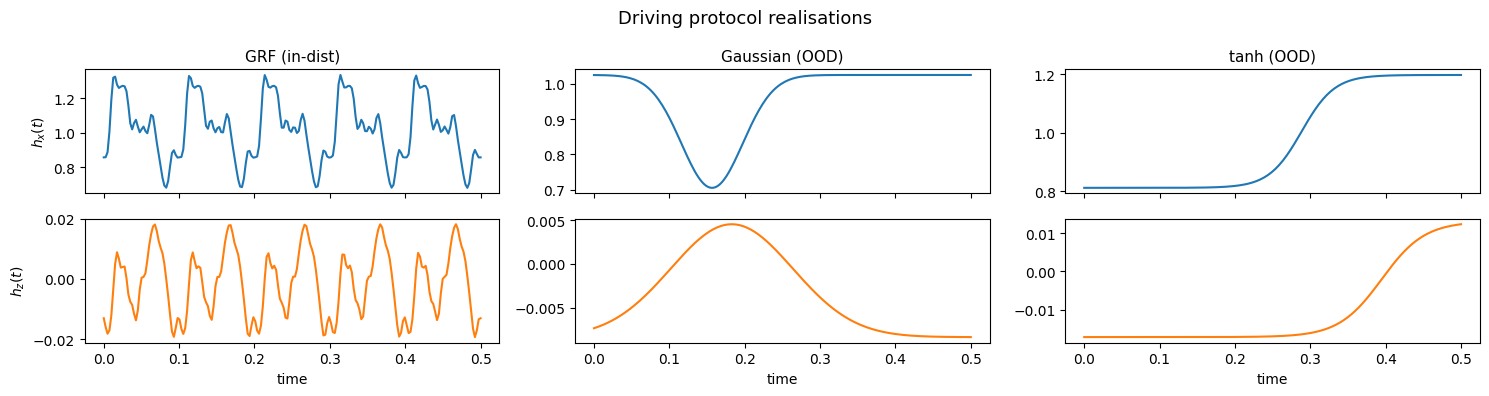

In [5]:
# ── Protocol generators ───────────────────────────────────────────────────────

def generate_gaussian_protocols(key, batch_size, t_steps, t_max):
    """OOD: Gaussian-pulse driving.  Returns (batch_size, t_steps, 2)."""
    keys = random.split(key, 8)
    t     = jnp.linspace(0.0, t_max, t_steps, dtype=jnp.float32)
    h_x0  = random.uniform(keys[0], (batch_size, 1), minval=0.95,       maxval=1.05)
    A_x   = random.uniform(keys[1], (batch_size, 1), minval=-0.40,      maxval=0.40)
    t_cx  = random.uniform(keys[2], (batch_size, 1), minval=0.15*t_max, maxval=0.85*t_max)
    sig_x = random.uniform(keys[3], (batch_size, 1), minval=0.08*t_max, maxval=0.22*t_max)
    hx    = h_x0 + A_x * jnp.exp(-0.5 * ((t[None, :] - t_cx) / sig_x) ** 2)
    hz0   = random.uniform(keys[4], (batch_size, 1), minval=-0.02,      maxval=0.02)
    A_z   = random.uniform(keys[5], (batch_size, 1), minval=-0.02,      maxval=0.02)
    t_cz  = random.uniform(keys[6], (batch_size, 1), minval=0.10*t_max, maxval=0.90*t_max)
    sig_z = random.uniform(keys[7], (batch_size, 1), minval=0.05*t_max, maxval=0.25*t_max)
    hz    = hz0 + A_z * jnp.exp(-0.5 * ((t[None, :] - t_cz) / sig_z) ** 2)
    return jnp.stack([hx, hz], axis=-1)


def generate_tanh_protocols(key, batch_size, t_steps, t_max):
    """OOD: tanh-step driving.  Returns (batch_size, t_steps, 2)."""
    keys  = random.split(key, 8)
    t     = jnp.linspace(0.0, t_max, t_steps, dtype=jnp.float32)
    h_x0  = random.uniform(keys[0], (batch_size, 1), minval=0.95,       maxval=1.05)
    A_x   = random.uniform(keys[1], (batch_size, 1), minval=-0.40,      maxval=0.40)
    t_cx  = random.uniform(keys[2], (batch_size, 1), minval=0.20*t_max, maxval=0.80*t_max)
    tau_x = random.uniform(keys[3], (batch_size, 1), minval=0.05*t_max, maxval=0.15*t_max)
    hx    = h_x0 + A_x * jnp.tanh((t[None, :] - t_cx) / tau_x)
    hz0   = random.uniform(keys[4], (batch_size, 1), minval=-0.02,      maxval=0.02)
    A_z   = random.uniform(keys[5], (batch_size, 1), minval=-0.02,      maxval=0.02)
    t_cz  = random.uniform(keys[6], (batch_size, 1), minval=0.20*t_max, maxval=0.80*t_max)
    tau_z = random.uniform(keys[7], (batch_size, 1), minval=0.05*t_max, maxval=0.15*t_max)
    hz    = hz0 + A_z * jnp.tanh((t[None, :] - t_cz) / tau_z)
    return jnp.stack([hx, hz], axis=-1)


PROTOCOL_FN = {
    "GRF (in-dist)": lp.generate_grf_trajectories,
    "Gaussian (OOD)": generate_gaussian_protocols,
    "tanh (OOD)":     generate_tanh_protocols,
}

# ── Preview one realisation of each family ───────────────────────────────────
fig, axes = plt.subplots(2, N_PROTOS, figsize=(5 * N_PROTOS, 4), sharex=True)
for col, (name, fn) in enumerate(PROTOCOL_FN.items()):
    h = np.asarray(fn(random.PRNGKey(PROTOCOL_SEEDS[name][0]), 1, T_STEPS, T_MAX)[0])
    axes[0, col].plot(time_grid, h[:, 0], color="tab:blue")
    axes[1, col].plot(time_grid, h[:, 1], color="tab:orange")
    axes[0, col].set_title(name, fontsize=11)
axes[0, 0].set_ylabel(r"$h_x(t)$")
axes[1, 0].set_ylabel(r"$h_z(t)$")
for ax in axes[1]:
    ax.set_xlabel("time")
fig.suptitle("Driving protocol realisations", fontsize=13)
fig.tight_layout()
plt.show()

In [6]:
# ── RK4 ───────────────────────────────────────────────────────────────────────

def _bits_to_index(bitstrings):
    """(n_states, n_spins) uint → (n_states,) integer index (little-endian)."""
    powers = jnp.left_shift(jnp.uint32(1), jnp.arange(bitstrings.shape[1], dtype=jnp.uint32))
    return jnp.sum(bitstrings.astype(jnp.uint32) * powers[None, :], axis=1)


def initial_columns_from_z_bitstrings(bitstrings):
    """(n_states, n_spins) int32 → (dim, n_states) complex64 Z-basis ket matrix."""
    n_states = int(bitstrings.shape[0])
    dim = 1 << int(bitstrings.shape[1])
    psi = jnp.zeros((dim, n_states), dtype=jnp.complex64)
    return psi.at[_bits_to_index(bitstrings), jnp.arange(n_states, dtype=jnp.int32)].set(1.0 + 0j)


def make_rk4_step(apply_H, dt_val):
    """Build a JIT-compiled RK4 step for a (dim, n_states) column matrix."""
    def _Hmat(mat, hx, hz):
        return jax.vmap(lambda col: apply_H(col, hx, hz), in_axes=1, out_axes=1)(mat)

    @jax.jit
    def step(psi, hx_curr, hz_curr, hx_next, hz_next):
        hx_mid = 0.5 * (hx_curr + hx_next)
        hz_mid = 0.5 * (hz_curr + hz_next)
        k1 = -1j * _Hmat(psi,                      hx_curr, hz_curr)
        k2 = -1j * _Hmat(psi + 0.5 * dt_val * k1,  hx_mid,  hz_mid)
        k3 = -1j * _Hmat(psi + 0.5 * dt_val * k2,  hx_mid,  hz_mid)
        k4 = -1j * _Hmat(psi +       dt_val * k3,  hx_next, hz_next)
        psi_new = psi + (dt_val / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
        return psi_new / jnp.clip(jnp.linalg.norm(psi_new, axis=0, keepdims=True), a_min=1e-12)

    return step


rk4_step = make_rk4_step(apply_H_exact, dt)

# ── Measurements ──────────────────────────────────────────────────────────────

def compute_sz(psi_cols):
    """⟨σz_i⟩ per site per state.

    psi_cols  : (dim, n_states) complex64
    returns   : (n_states, n_spins) float32
    """
    prob  = jnp.abs(psi_cols) ** 2                               # (dim, n_states)
    signs = 1.0 - 2.0 * all_z_bits.astype(jnp.float32)          # (dim, n_spins); +1 for bit=0
    return (signs.T @ prob).T                                    # (n_states, n_spins)


def make_compute_obs(bonds_i, bonds_j, n_spins_val, j_zz=lp.J_zz):
    """Build a JIT-compiled function computing ⟨X⟩, ⟨ZZ⟩, ⟨E(t)⟩ for a batch of states.

    H = -J_zz Σ_{<ij>} Z_i Z_j  -  h_z Σ_i Z_i  -  h_x Σ_i X_i
    """
    bond_pairs = tuple((int(bi), int(bj)) for bi, bj in zip(bonds_i, bonds_j))

    @jax.jit
    def compute_obs(psi_cols, h_x_val, h_z_val):
        """psi_cols: (dim, n_states) complex, normalised.
        Returns exp_X, exp_ZZ, exp_E each of shape (n_states,)."""
        dim = psi_cols.shape[0]
        batch = psi_cols.shape[1]
        idx  = jnp.arange(dim, dtype=jnp.int32)
        prob = jnp.abs(psi_cols) ** 2  # (dim, n_states)

        # ⟨ZZ⟩ = Σ_{<ij>} Σ_k |ψ_k|² z_i(k) z_j(k)   (diagonal)
        zz_diag = jnp.zeros(dim, dtype=jnp.float32)
        for bi, bj in bond_pairs:
            zi = (1 - 2 * ((idx >> bi) & 1)).astype(jnp.float32)
            zj = (1 - 2 * ((idx >> bj) & 1)).astype(jnp.float32)
            zz_diag = zz_diag + zi * zj
        exp_ZZ = jnp.sum(zz_diag[:, None] * prob, axis=0)

        # ⟨Z_sum⟩ = Σ_i Σ_k |ψ_k|² z_i(k)
        z_sum_diag = jnp.zeros(dim, dtype=jnp.float32)
        for i in range(n_spins_val):
            z_sum_diag = z_sum_diag + (1 - 2 * ((idx >> i) & 1)).astype(jnp.float32)
        exp_Z_sum = jnp.sum(z_sum_diag[:, None] * prob, axis=0)

        # ⟨X⟩ = Σ_i Re(ψ† X_i ψ)   (X_i flips spin i)
        psi_tensor = psi_cols.reshape((2,) * n_spins_val + (batch,))
        exp_X = jnp.zeros(batch, dtype=jnp.float32)
        for i in range(n_spins_val):
            flipped = jnp.flip(psi_tensor, axis=n_spins_val - 1 - i).reshape(dim, batch)
            exp_X = exp_X + jnp.real(jnp.sum(jnp.conj(psi_cols) * flipped, axis=0))

        exp_E = (-j_zz) * exp_ZZ + (-h_z_val) * exp_Z_sum + (-h_x_val) * exp_X
        return exp_X, exp_ZZ, exp_E

    return compute_obs


compute_obs = make_compute_obs(bonds_i_np, bonds_j_np, n_spins)

# ── Benchmark loop ────────────────────────────────────────────────────────────

def run_benchmark(h_state, bitstrings):
    """Exact RK4 vs model for one protocol and a batch of initial Z-basis states.

    Parameters
    ----------
    h_state    : (T_STEPS, 2) float32 – driving protocol
    bitstrings : (n_states, n_spins) int32

    Returns
    -------
    fidelity : (T_STEPS, n_states)          float32
    sz_exact : (T_STEPS, n_states, n_spins) float32
    sz_pred  : (T_STEPS, n_states, n_spins) float32
    X_exact  : (T_STEPS, n_states)          float32   ⟨X⟩ = Σ_i ⟨X_i⟩
    ZZ_exact : (T_STEPS, n_states)          float32   ⟨ZZ⟩ = Σ_{<ij>} ⟨Z_i Z_j⟩
    E_exact  : (T_STEPS, n_states)          float32   ⟨E(t)⟩
    X_pred, ZZ_pred, E_pred : same shapes, from model
    """
    m_traj, _ = model.encode_field(h_state[None, :, :])
    m_traj = m_traj[0]  # (T_STEPS, ctx, d)

    psi_exact = initial_columns_from_z_bitstrings(bitstrings)  # (dim, n_states)

    fidelity_list = []
    sz_exact_list, sz_pred_list = [], []
    X_exact_list,  ZZ_exact_list,  E_exact_list  = [], [], []
    X_pred_list,   ZZ_pred_list,   E_pred_list   = [], [], []

    for t_idx in range(T_STEPS):
        h_x_t = h_state[t_idx, 0]
        h_z_t = h_state[t_idx, 1]

        psi_pred = lp.apply_propagator_to_z_states(
            model, m_traj[t_idx], bitstrings, all_z_bits, ALPHA_CHUNK
        )  # (dim, n_states)

        overlaps = jnp.sum(jnp.conj(psi_exact) * psi_pred, axis=0)
        fidelity_list.append(np.asarray(jnp.abs(overlaps) ** 2, dtype=np.float32))

        sz_exact_list.append(np.asarray(compute_sz(psi_exact), dtype=np.float32))
        sz_pred_list.append( np.asarray(compute_sz(psi_pred),  dtype=np.float32))

        ex_X, ex_ZZ, ex_E = compute_obs(psi_exact, h_x_t, h_z_t)
        X_exact_list.append( np.asarray(ex_X,  dtype=np.float32))
        ZZ_exact_list.append(np.asarray(ex_ZZ, dtype=np.float32))
        E_exact_list.append( np.asarray(ex_E,  dtype=np.float32))

        pr_X, pr_ZZ, pr_E = compute_obs(psi_pred.astype(jnp.complex64), h_x_t, h_z_t)
        X_pred_list.append( np.asarray(pr_X,  dtype=np.float32))
        ZZ_pred_list.append(np.asarray(pr_ZZ, dtype=np.float32))
        E_pred_list.append( np.asarray(pr_E,  dtype=np.float32))

        if t_idx < T_STEPS - 1:
            psi_exact = rk4_step(
                psi_exact,
                h_state[t_idx,     0], h_state[t_idx,     1],
                h_state[t_idx + 1, 0], h_state[t_idx + 1, 1],
            )

    return (
        np.stack(fidelity_list,  axis=0),   # (T_STEPS, n_states)
        np.stack(sz_exact_list,  axis=0),   # (T_STEPS, n_states, n_spins)
        np.stack(sz_pred_list,   axis=0),
        np.stack(X_exact_list,   axis=0),   # (T_STEPS, n_states)
        np.stack(ZZ_exact_list,  axis=0),
        np.stack(E_exact_list,   axis=0),
        np.stack(X_pred_list,    axis=0),
        np.stack(ZZ_pred_list,   axis=0),
        np.stack(E_pred_list,    axis=0),
    )


print("All helpers and benchmark function defined.")

All helpers and benchmark function defined.


In [9]:
results = {}  # proto_name → list[dict] one dict per seed

for proto_name, seeds in PROTOCOL_SEEDS.items():
    _, bitstrings = lp.sample_state_benchmark_specs(
        random.PRNGKey(STATE_SEEDS[proto_name]), NUM_STATES, n_spins, "z"
    )
    bs_labels = [
        "".join(str(int(b)) for b in np.asarray(bitstrings[i]))
        for i in range(NUM_STATES)
    ]
    print(f"[{proto_name}] initial states:", [f"|{s}⟩" for s in bs_labels])

    results[proto_name] = []
    for seed in seeds:
        print(f"  protocol seed={seed}")
        h = jnp.asarray(
            PROTOCOL_FN[proto_name](random.PRNGKey(seed), 1, T_STEPS, T_MAX)[0]
        )  # (T_STEPS, 2)
        fidelity, sz_exact, sz_pred, X_exact, ZZ_exact, E_exact, X_pred, ZZ_pred, E_pred = run_benchmark(h, bitstrings)
        results[proto_name].append(
            dict(seed=seed, h=np.asarray(h),
                 bitstrings=np.asarray(bitstrings), bs_labels=bs_labels,
                 fidelity=fidelity, sz_exact=sz_exact, sz_pred=sz_pred,
                 X_exact=X_exact, ZZ_exact=ZZ_exact, E_exact=E_exact,
                 X_pred=X_pred,   ZZ_pred=ZZ_pred,   E_pred=E_pred)
        )
        print(f"    avg F={np.mean(fidelity):.4f}   final F={np.mean(fidelity[-1]):.4f}")

print("\nAll benchmarks complete.")

[GRF (in-dist)] initial states: ['|1110010011010100⟩']
  protocol seed=1899
    avg F=0.9860   final F=0.9854
[Gaussian (OOD)] initial states: ['|1100110011010110⟩']
  protocol seed=114514
    avg F=0.9899   final F=0.9919
[tanh (OOD)] initial states: ['|0110011011011011⟩']
  protocol seed=1999
    avg F=0.9877   final F=0.9870

All benchmarks complete.


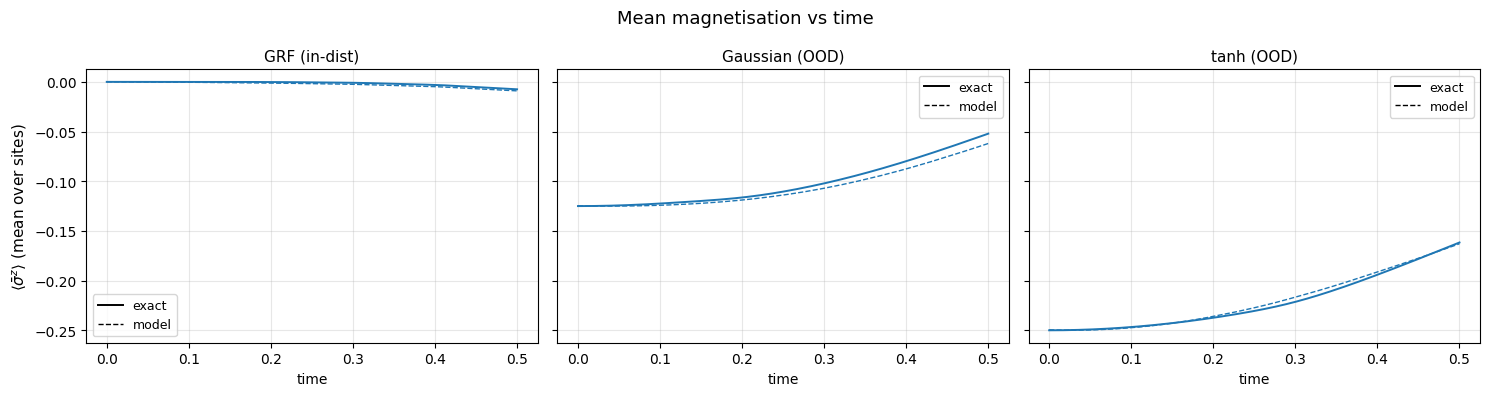

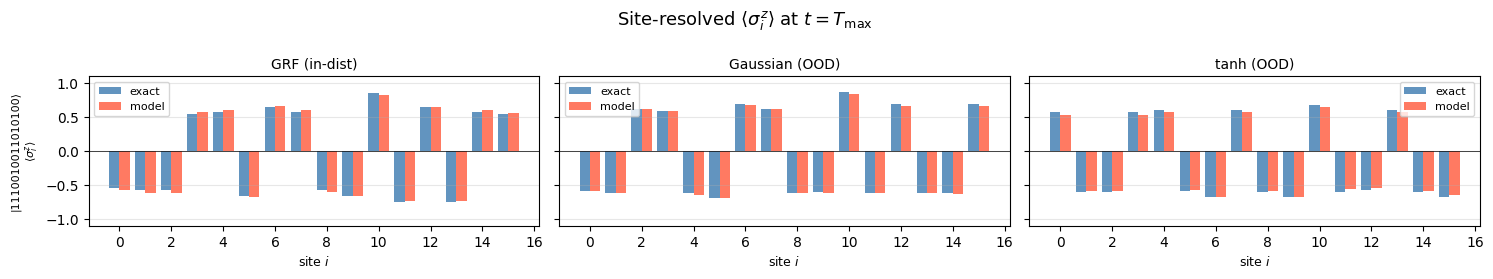

In [14]:
proxy_lines = [
    Line2D([0], [0], color="k", lw=1.4,              label="exact"),
    Line2D([0], [0], color="k", lw=1.0, ls="--",     label="model"),
]

# ── Mean ⟨σz⟩ vs time ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, N_PROTOS, figsize=(5 * N_PROTOS, 4), sharey=True)
if N_PROTOS == 1:
    axes = [axes]

for ax, (proto_name, runs) in zip(axes, results.items()):
    run = runs[0]
    sz_ex_mean = run["sz_exact"].mean(axis=2)
    sz_pr_mean = run["sz_pred"].mean(axis=2)
    for s in range(NUM_STATES):
        ax.plot(time_grid, sz_ex_mean[:, s], color=COLORS[s], lw=1.4)
        ax.plot(time_grid, sz_pr_mean[:, s], color=COLORS[s], lw=1.0, ls="--")
    ax.legend(handles=proxy_lines, fontsize=9)
    ax.set_xlabel("time"); ax.set_title(proto_name, fontsize=11); ax.grid(alpha=0.3)

axes[0].set_ylabel(r"$\langle\bar{\sigma}^z\rangle$ (mean over sites)", fontsize=11)
fig.suptitle("Mean magnetisation vs time", fontsize=13)
fig.tight_layout()
#plt.savefig("sz_mean_vs_time.pdf", bbox_inches="tight")
plt.show()

# ── Site-resolved ⟨σz_i⟩ at final time ──────────────────────────────────────
fig, axes = plt.subplots(NUM_STATES, N_PROTOS,
                         figsize=(5 * N_PROTOS, 2.8 * NUM_STATES),
                         sharey=True, sharex=True)
axes = np.array(axes).reshape(NUM_STATES, N_PROTOS)

site_idx = np.arange(n_spins)
for col, (proto_name, runs) in enumerate(results.items()):
    run = runs[0]
    bs_labels = run["bs_labels"]
    sz_ex = run["sz_exact"][-1]  # (n_states, n_spins) at t = T_MAX
    sz_pr = run["sz_pred"][-1]
    for row in range(NUM_STATES):
        ax = axes[row, col]
        ax.bar(site_idx - 0.2, sz_ex[row], width=0.4, label="exact", color="steelblue", alpha=0.85)
        ax.bar(site_idx + 0.2, sz_pr[row], width=0.4, label="model", color="tomato",    alpha=0.85)
        ax.axhline(0, color="k", lw=0.5); ax.set_ylim(-1.1, 1.1); ax.grid(axis="y", alpha=0.3)
        if col == 0:
            ax.set_ylabel(f"|{bs_labels[row]}⟩\n" r"$\langle\sigma^z_i\rangle$", fontsize=8)
        if row == 0:
            ax.set_title(proto_name, fontsize=10); ax.legend(fontsize=8)
        if row == NUM_STATES - 1:
            ax.set_xlabel("site $i$", fontsize=9)

fig.suptitle(r"Site-resolved $\langle\sigma^z_i\rangle$ at $t = T_{\max}$", fontsize=13)
fig.tight_layout()
#plt.savefig("sz_site_final.pdf", bbox_inches="tight")
plt.show()

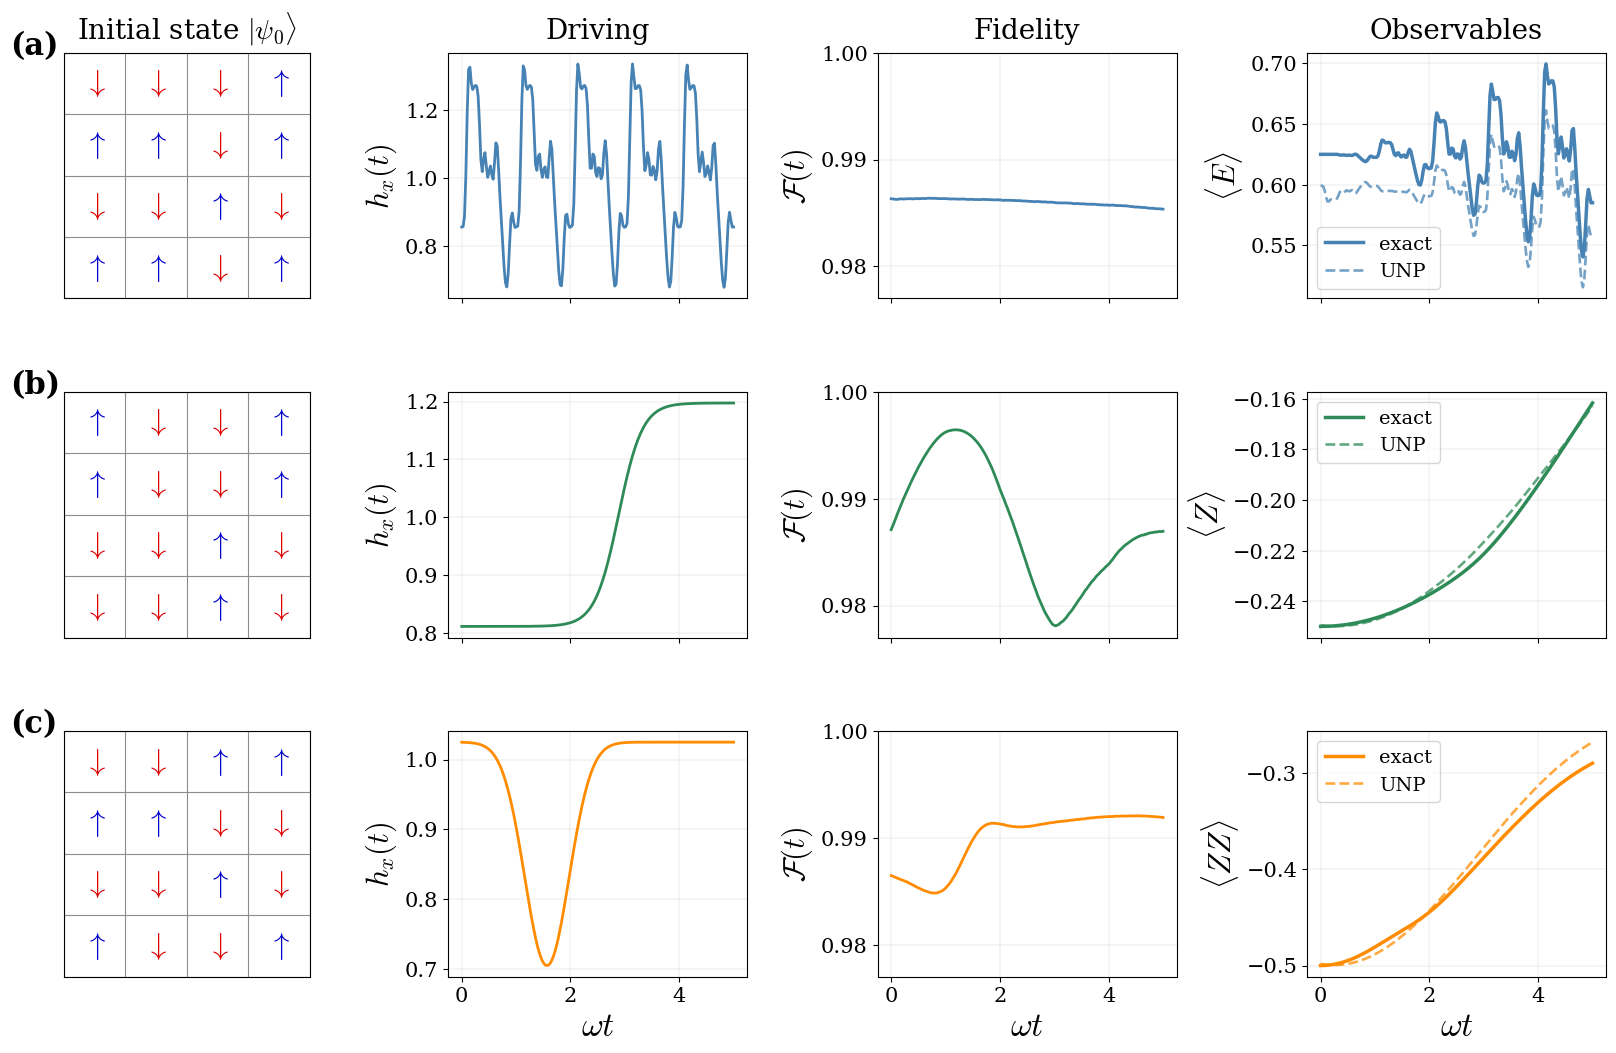

Saved -> 4by4_overview.pdf


In [36]:

# ============================================================
# 3×4 summary figure
# rows : GRF (in-dist) | tanh (OOD) | Gaussian (OOD)
# cols : initial state (4×4 spin grid) | hx(t) | fidelity F(t) | per-row observable
# ============================================================

import matplotlib as mpl

# ── Font / math settings ──────────────────────────────────────────────────────
plt.rcParams.update({
    "text.usetex":      False,
    "mathtext.fontset": "cm",
    "font.family":      "serif",
    "font.size":        18,
    "axes.titlesize":   20,
    "axes.labelsize":   18,
    "xtick.labelsize":  15,
    "ytick.labelsize":  15,
    "legend.fontsize":  14,
})

tg = time_grid * 10   # rescaled time axis

# ── Derive <Z> = Σ_i <σz_i> for every run (shape: T_STEPS × n_states) ───────
for runs in results.values():
    for run in runs:
        run["Z_exact"] = run["sz_exact"].sum(axis=2)
        run["Z_pred"]  = run["sz_pred"].sum(axis=2)

# ── Manual observable selection for the last column ──────────────────────────
LAST_COL_OBS = {
    0: ("E_exact",  "E_pred",  r"$\langle E \rangle$"),
    1: ("Z_exact",  "Z_pred",  r"$\langle Z \rangle$"),
    2: ("ZZ_exact", "ZZ_pred", r"$\langle ZZ \rangle$"),
}

ROW_BG = ["#EFF5FB", "#EAFAF1", "#FEF9E7"]   # light blue / green / yellow


ROW_CONFIGS = [
    ("GRF (in-dist)",  "steelblue"),
    ("tanh (OOD)",     "seagreen"),
    ("Gaussian (OOD)", "darkorange"),
]

COL_TITLES = [
    r"Initial state $|\psi_0\rangle$",
    r"Driving",
    r"Fidelity",
    r"Observables",
]

COLOR_UP   = "#0000CD"   # medium blue (maximally saturated)
COLOR_DOWN = "#DD0000"   # strong red


def plot_spin_config_4x4(ax, bitstring, lx=4, ly=4):
    """Render a snake-ordered 0/1 bitstring as a 4×4 grid of up/down arrows."""
    bs = np.asarray(bitstring).ravel()

    for i, bit in enumerate(bs):
        row = i // lx
        col_in_row = i % lx
        x = col_in_row if row % 2 == 0 else lx - 1 - col_in_row
        y = (ly - 1) - row
        char  = r"$\uparrow$" if bit == 0 else r"$\downarrow$"
        color = COLOR_UP if bit == 0 else COLOR_DOWN
        ax.text(x, y, char, ha="center", va="center",
                fontsize=22, color=color, fontweight="bold")

    boundaries = np.arange(-0.5, lx, 1.0)
    for b in boundaries:
        ax.axvline(b, color="0.55", lw=0.8, zorder=0)
        ax.axhline(b, color="0.55", lw=0.8, zorder=0)

    ax.set_xlim(-0.5, lx - 0.5)
    ax.set_ylim(-0.5, ly - 0.5)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_linewidth(0.8)


# ── figure ────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(
    3, 4, figsize=(20, 12),
    gridspec_kw={"wspace": 0.45, "hspace": 0.38, "width_ratios": [1.4, 1.6, 1.6, 1.6]},
)

for col, title in enumerate(COL_TITLES):
    axes[0, col].set_title(title, fontsize=20, pad=10)

ROW_PANEL_LABELS = ["(a)", "(b)", "(c)"]

for row, (proto_name, color) in enumerate(ROW_CONFIGS):
    run = results[proto_name][0]
    h   = run["h"]
    fid = run["fidelity"]
    bs  = run["bitstrings"][0]
    s   = 0
    is_bottom = (row == 2)



    obs_ex, obs_pr, obs_ylabel = LAST_COL_OBS[row]

    # ── col 0: spin configuration ─────────────────────────────────────────
    ax = axes[row, 0]
    plot_spin_config_4x4(ax, bs)
    ax.text(-0.22, 1.09, ROW_PANEL_LABELS[row],
            transform=ax.transAxes, fontsize=22, fontweight="bold",
            va="top", ha="left")

    # ── col 1: hx(t) ──────────────────────────────────────────────────────
    ax = axes[row, 1]
    ax.plot(tg, h[:, 0], color=color, lw=2.0)
    ax.set_ylabel(r"$h_x(t)$", fontsize=22)
    ax.grid(True, lw=0.3, alpha=0.6)
    if is_bottom:
        ax.set_xlabel(r"$\omega t$", fontsize=24)
    else:
        ax.tick_params(labelbottom=False)

    # ── col 2: fidelity ───────────────────────────────────────────────────
    ax = axes[row, 2]
    ax.plot(tg, fid[:, s], color=color, lw=2.0)
    ax.set_ylim(0.977, 1.00)
    ax.set_yticks([0.98, 0.99, 1.00])
    ax.set_ylabel(
        r"$\mathcal{F}(t)$",
        fontsize=22,
    )
    ax.grid(True, lw=0.3, alpha=0.6)
    if is_bottom:
        ax.set_xlabel(r"$\omega t$", fontsize=24)
    else:
        ax.tick_params(labelbottom=False)

    # ── col 3: per-row observable (normalised by N) ───────────────────────
    ax = axes[row, 3]
    ax.plot(tg, run[obs_ex][:, s] / n_spins, color=color, lw=2.5,
            label="exact")
    ax.plot(tg, run[obs_pr][:, s] / n_spins, color=color, lw=1.9,
            ls="--", alpha=0.75, label="UNP")
    ax.set_ylabel(obs_ylabel, fontsize=22)
    ax.legend(loc="best")
    ax.grid(True, lw=0.3, alpha=0.6)
    if is_bottom:
        ax.set_xlabel(r"$\omega t$", fontsize=24)
    else:
        ax.tick_params(labelbottom=False)


plt.savefig("4by4_overview.pdf", bbox_inches="tight", dpi=300)
plt.show()
print("Saved -> 4by4_overview.pdf")

plt.rcParams.update(mpl.rcParamsDefault)


In [ ]:

# ── Save all results to 4by4_results.npz ─────────────────────────────────────
# Layout: one entry per (protocol, quantity), e.g. "GRF_hx", "tanh_X_exact"
# All arrays retain their original shapes (T_STEPS, ...).

PROTO_SHORT = {
    "GRF (in-dist)":  "GRF",
    "tanh (OOD)":     "tanh",
    "Gaussian (OOD)": "Gaussian",
}

save_dict = {"time_grid": time_grid}

for proto_name, short in PROTO_SHORT.items():
    run = results[proto_name][0]
    h   = run["h"]                          # (T_STEPS, 2)

    # driving fields
    save_dict[f"{short}_hx"] = h[:, 0]
    save_dict[f"{short}_hz"] = h[:, 1]

    # fidelity
    save_dict[f"{short}_fidelity"] = run["fidelity"]

    # observables — exact and model
    for key in ("X_exact", "X_pred", "ZZ_exact", "ZZ_pred", "E_exact", "E_pred"):
        save_dict[f"{short}_{key}"] = run[key]

    # <Z> = Σ_i <σz_i>  (derived from sz arrays)
    save_dict[f"{short}_Z_exact"] = run["sz_exact"].sum(axis=2)
    save_dict[f"{short}_Z_pred"]  = run["sz_pred"].sum(axis=2)

np.savez("4by4_results.npz", **save_dict)
print("Saved → 4by4_results.npz")
print("Keys:", sorted(save_dict.keys()))


Saved → 4by4_results.npz
Keys: ['GRF_E_exact', 'GRF_E_pred', 'GRF_X_exact', 'GRF_X_pred', 'GRF_ZZ_exact', 'GRF_ZZ_pred', 'GRF_Z_exact', 'GRF_Z_pred', 'GRF_fidelity', 'GRF_hx', 'GRF_hz', 'Gaussian_E_exact', 'Gaussian_E_pred', 'Gaussian_X_exact', 'Gaussian_X_pred', 'Gaussian_ZZ_exact', 'Gaussian_ZZ_pred', 'Gaussian_Z_exact', 'Gaussian_Z_pred', 'Gaussian_fidelity', 'Gaussian_hx', 'Gaussian_hz', 'tanh_E_exact', 'tanh_E_pred', 'tanh_X_exact', 'tanh_X_pred', 'tanh_ZZ_exact', 'tanh_ZZ_pred', 'tanh_Z_exact', 'tanh_Z_pred', 'tanh_fidelity', 'tanh_hx', 'tanh_hz', 'time_grid']


In [ ]:
print(f"{'Protocol':<22} {'Seed':>6}  {'avg F̄':>8}  {'final F̄':>9}  {'RMSE σz':>9}  {'MAE X':>7}  {'MAE ZZ':>8}  {'MAE E':>7}")
print("-" * 90)
for proto_name, runs in results.items():
    for run in runs:
        fid    = run["fidelity"]
        sz_ex  = run["sz_exact"]
        sz_pr  = run["sz_pred"]
        avg_F  = float(fid.mean())
        fin_F  = float(fid[-1].mean())
        rmse   = float(np.sqrt(np.mean((sz_ex - sz_pr) ** 2)))
        mae_X  = float(np.mean(np.abs(run["X_exact"]  - run["X_pred"])))
        mae_ZZ = float(np.mean(np.abs(run["ZZ_exact"] - run["ZZ_pred"])))
        mae_E  = float(np.mean(np.abs(run["E_exact"]  - run["E_pred"])))
        print(f"{proto_name:<22} {run['seed']:>6}  {avg_F:>8.4f}  {fin_F:>9.4f}  {rmse:>9.5f}  {mae_X:>7.4f}  {mae_ZZ:>8.4f}  {mae_E:>7.4f}")

Protocol                 Seed    avg F̄   final F̄    RMSE σz    MAE X    MAE ZZ    MAE E
------------------------------------------------------------------------------------------
GRF (in-dist)            1899    0.9860     0.9854    0.01666   0.5431    0.1326   0.4805
Gaussian (OOD)         114514    0.9899     0.9919    0.00949   0.4723    0.1560   0.5488
tanh (OOD)               1999    0.9877     0.9869    0.02498   0.3952    0.0287   0.3948
